In [53]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

SMALL_SIZE = 11
MEDIUM_SIZE = 15
BIGGER_SIZE = 20

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
path_endings=["fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              "fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen", "fargo_sigslop_1.5_2gen", "fargo_fiducial_companion" ]
titles = ["fiducial", "$M_p = 10 M_{jup}$", "$M_p = 2 M_{Jup}$", "$\\alpha = 10^{-2}$", "$\\alpha = 10^{-4}$", "$\\gamma = 0$",
          "$\\gamma = 0.5$", "$\\gamma = -2$", "$\\gamma = 1.5$"]
paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])

In [3]:


frames = [0,1,10,100]

rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in frames:
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0)

rho_cube = rho_cube*mstar/r0**2

/scratch/3208986/ipykernel_3180633/1189089890.py:15: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[0][-1]),cmap=cm.Oranges_r)


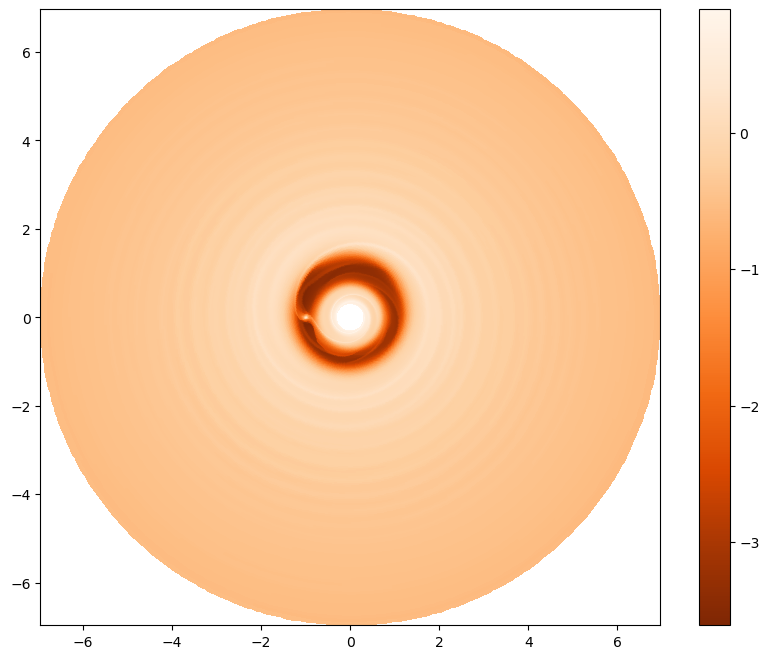

In [4]:
## make this a round plot so I know what's going on.

Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, phi, indexing='ij')

X = R*np.cos(PHI)
Y = R*np.sin(PHI)

plt.figure(figsize=(10,8))
plt.pcolormesh(X, Y,np.log10(rho_cube[0][-1]),cmap=cm.Oranges_r)
plt.colorbar()

# Gap width for different planet masses

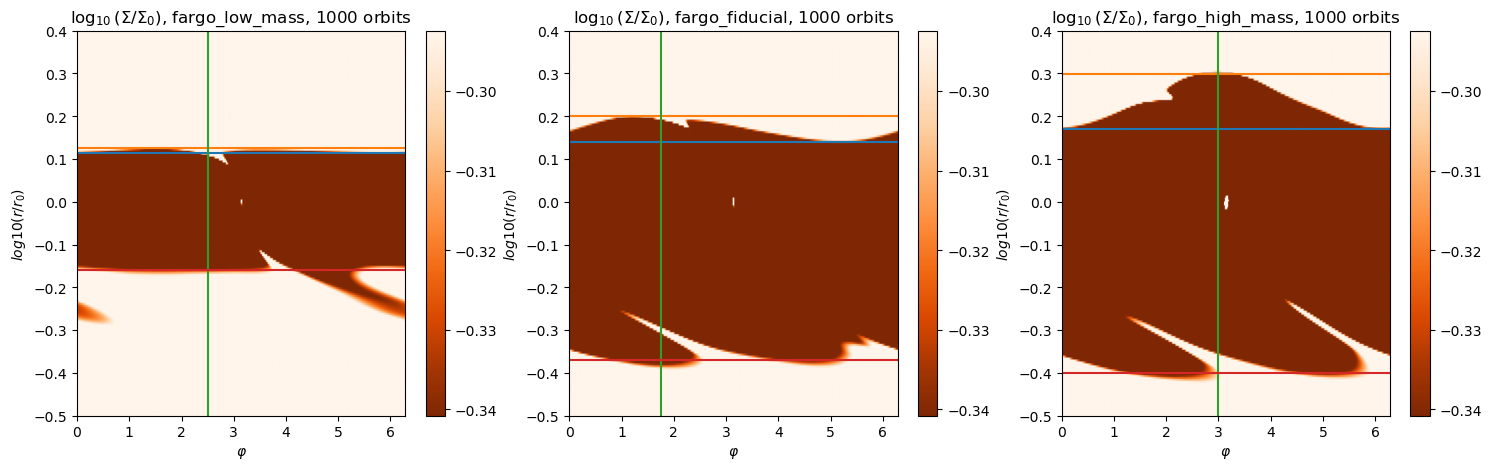

In [5]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_mass=[2,0,1]

r_in_log = [0.115,0.14,0.17]
r_out_log = [0.125,0.20,0.30]
phi_ellipse = [2.5,4.9-np.pi,3.0]
r_inner_log = [-0.16,-0.37,-0.4]

lim = 0.5

plt.figure(figsize=(18,5))
frame = 100

for it,i in enumerate(index_for_mass):
    path = paths[i]
    
        
    plt.subplot(1,3,it+1)
    
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (np.log10(lim+0.01),np.log10(lim-0.01)))
    plt.plot([0,np.pi*2],[r_in_log[it],r_in_log[it]])
    plt.plot([0,np.pi*2],[r_out_log[it],r_out_log[it]])
    plt.plot([phi_ellipse[it], phi_ellipse[it]],[-0.5,0.8])

    plt.plot([0,np.pi*2],[r_inner_log[it], r_inner_log[it]])
    
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(-0.5,0.4)
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()


r_in: 1.4791083881682074
r_out: 1.9952623149688795
Eccentricity for fargo_high_mass: 0.14856040730904885


/scratch/3208986/ipykernel_3180633/3340943682.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


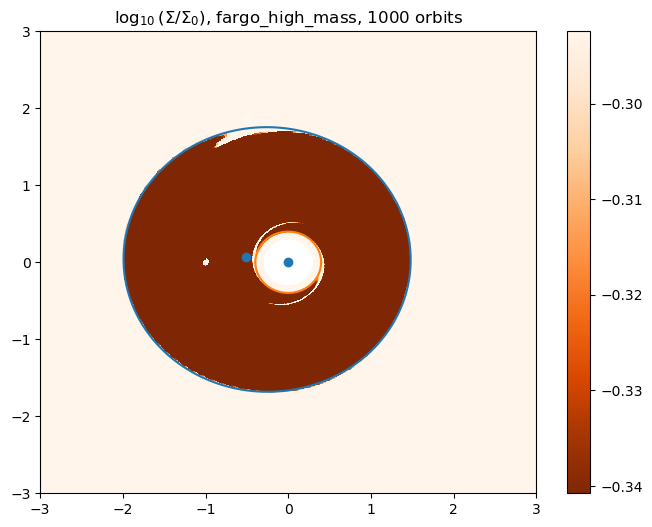

In [6]:
# index_for_mass=[2,0,1]
model_ind = 1

r_in = np.power(10,0.17)
r_out = np.power(10,0.30)

r_inner = np.power(10,-0.4)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 3.0
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)

plt.plot(r_inner * np.cos(philist), r_inner*np.sin(philist), zorder=3)

plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

r_in: 1.3803842646028848
r_out: 1.5848931924611136
Eccentricity for fargo_fiducial: 0.06896788945366301
e : 0.10225446392911441


/scratch/3208986/ipykernel_3180633/2273169929.py:33: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


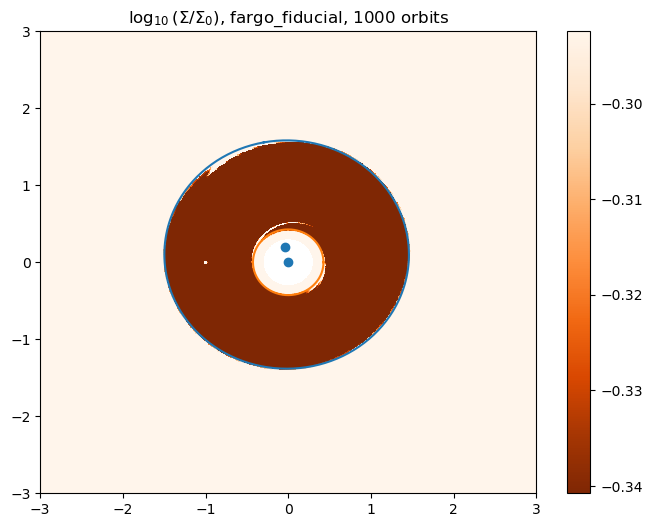

In [7]:
# index_for_mass=[2,0,1]
model_ind = 0

r_in = np.power(10,0.14)
r_out = np.power(10,0.20)
r_inner = np.power(10,-0.37)
print(f"r_in: {r_in}\nr_out: {r_out}")

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)

path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")
print(f"e : {e}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 4.9 - np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.plot(r_inner * np.cos(philist), r_inner*np.sin(philist), zorder=3)

plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.colorbar()

r_in: 1.3031667784522993
r_out: 1.333521432163324
Eccentricity for fargo_low_mass: 0.011512416822289855
e : 0.015177326855512319


/scratch/3208986/ipykernel_3180633/3348367660.py:34: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


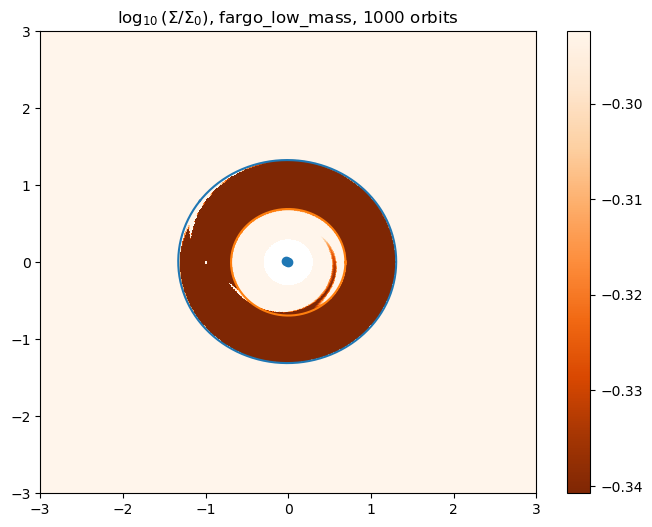

In [8]:
# index_for_mass=[2,0,1]
model_ind = 2

r_in = np.power(10,0.115)
r_out = np.power(10,0.125)
r_inner = np.power(10,-0.16)
print(f"r_in: {r_in}\nr_out: {r_out}")

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)

path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")
print(f"e : {e}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 2.5
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.plot(r_inner * np.cos(philist), r_inner*np.sin(philist), zorder=3)


plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.colorbar()

[0.01151242 0.06896789 0.14856041]


Text(0, 0.5, 'eccentricity')

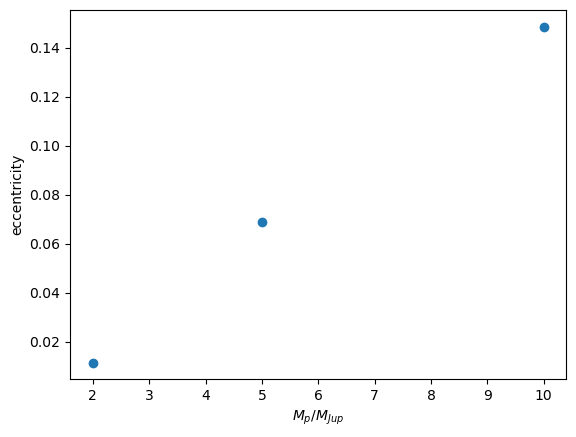

In [9]:
## make a plot for the eccentricities.
r_in_log = [0.115,0.14,0.17]
r_out_log = [0.125,0.20,0.30]
r_inner_log = [-0.16,-0.37,-0.4]

r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
print(ecc)

plt.scatter([2,5,10],ecc)
plt.xlabel("$M_p/M_{Jup}$")
plt.ylabel("eccentricity")

Text(0, 0.5, 'Gap width [$r_0$]')

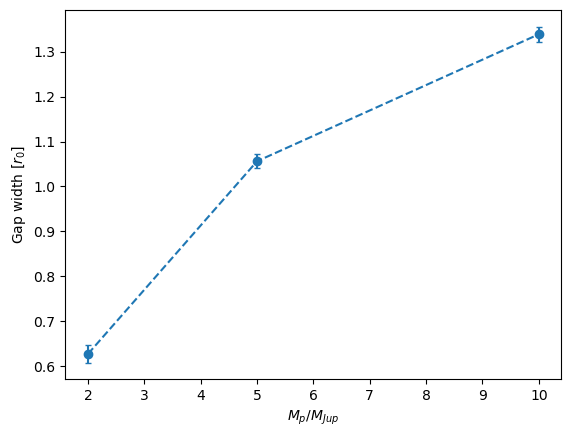

In [10]:
from uncertainties import ufloat

## make a plot for the eccentricities.
r_in_log = [ufloat(0.115,0.005),ufloat(0.14,0.005),ufloat(0.17,0.005)]
r_out_log = [ufloat(0.125,0.005),ufloat(0.20,0.005),ufloat(0.30,0.005)]
r_inner_log = [ufloat(-0.16,0.01),ufloat(-0.37,0.01),ufloat(-0.4,0.01)]

r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)
r_inner = np.power(10,r_inner_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a

gap_width = a-r_inner
w_values = [ee.nominal_value for ee in gap_width]
w_errs = [ee.std_dev for ee in gap_width]

plt.errorbar([2,5,10],w_values, yerr = w_errs, fmt="o--", capsize=2)
plt.xlabel("$M_p/M_{Jup}$")
plt.ylabel("Gap width [$r_0$]")

### Try again, but now with azimuthal averages.

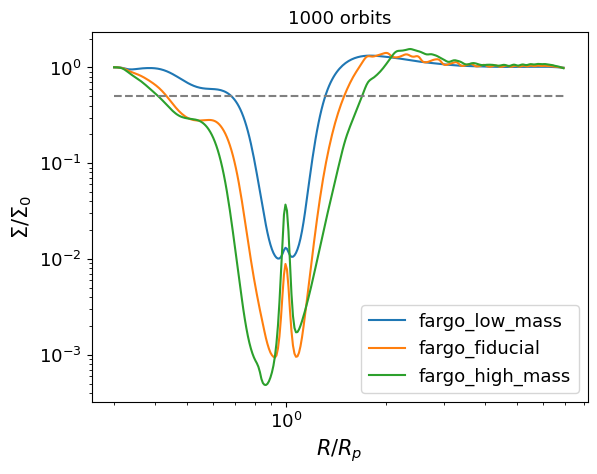

In [36]:
rho_mean = np.mean(rho_cube, axis=3)


for i in index_for_mass:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[43:-5]}")
plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()

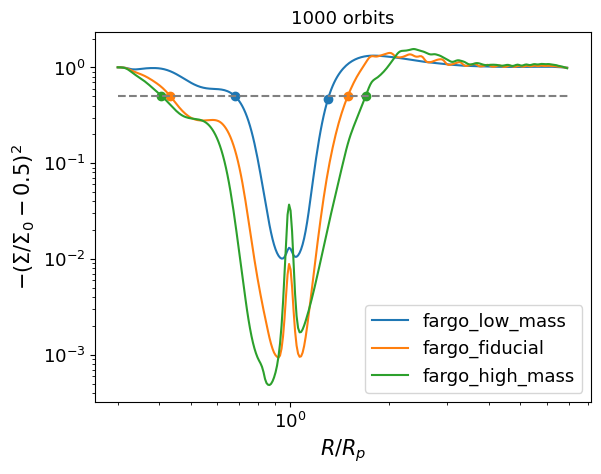

In [37]:

from scipy.signal import argrelextrema
gap_width = []

for i in index_for_mass:
    path = paths[i]
    weird = -(rho_mean[i][-1]/rho_mean[i][0]-0.5)**2
    
    #plt.plot(r_list,weird, label=f"{path[43:-5]}")
    local_max = argrelextrema(weird, np.greater)
    bound = []
    for l in local_max[0]:
        if weird[l]>-0.01:
            bound.append(l)
    #plt.scatter(r_list[bound],weird[bound])
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[43:-5]}")
    plt.scatter(r_list[bound],rho_mean[i][-1][bound]/rho_mean[i][0][bound])

    r_left = ufloat(r_list[bound[0]],r_list[bound[0]+1]-r_list[bound[0]])
    r_right = ufloat(r_list[bound[1]],r_list[bound[1]+1]-r_list[bound[1]])
    gap_width.append(r_right-r_left)
    
plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$-(\\Sigma/\\Sigma_0 - 0.5)^2$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()

[ 78 140]
[ 35 153]
[ 29 164]


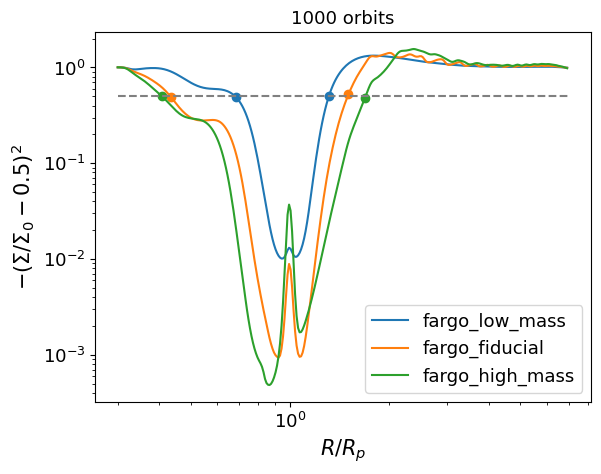

In [38]:

gap_width_sign_change = []
for i in index_for_mass:
    path = paths[i]
    weird = (rho_mean[i][-1]/rho_mean[i][0]-0.5)
    sign_changes = np.where(np.sign(weird[:-1]) != np.sign(weird[1:]))[0]
    r_sign = []
    sig_sign = []
    r_sign_err=[]
    print(sign_changes)
    for s in sign_changes:
        r_sign.append((r_list[s]+r_list[s+1])/2)
        r_sign_err.append((r_list[s+1]-r_list[s])/2)
        sig_sign.append((rho_mean[i][-1][s]/rho_mean[i][0][s]+rho_mean[i][-1][s+1]/rho_mean[i][0][s+1])/2)
    
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{path[43:-5]}")
    plt.scatter(r_sign, sig_sign)

    r_left = ufloat(r_sign[0], r_sign_err[0])
    r_right = ufloat(r_sign[1], r_sign_err[1])
    gap_width_sign_change.append(r_right-r_left)
    
plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$-(\\Sigma/\\Sigma_0 - 0.5)^2$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()

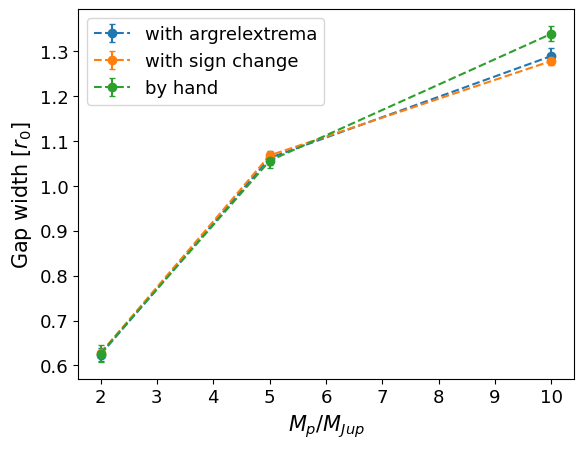

In [39]:
from uncertainties import ufloat

## make a plot for the eccentricities.
r_in_log = [ufloat(0.115,0.005),ufloat(0.14,0.005),ufloat(0.17,0.005)]
r_out_log = [ufloat(0.125,0.005),ufloat(0.20,0.005),ufloat(0.30,0.005)]
r_inner_log = [ufloat(-0.16,0.01),ufloat(-0.37,0.01),ufloat(-0.4,0.01)]

r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)
r_inner = np.power(10,r_inner_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a

gap_width_hand = a-r_inner
w_values_h = [ee.nominal_value for ee in gap_width_hand]
w_errs_h = [ee.std_dev for ee in gap_width_hand]

w_values = [ee.nominal_value for ee in gap_width]
w_errs = [ee.std_dev for ee in gap_width]

w_values_s = [ee.nominal_value for ee in gap_width_sign_change]
w_errs_s = [ee.std_dev for ee in gap_width_sign_change]


plt.errorbar([2,5,10],w_values, yerr = w_errs, fmt="o--", capsize=2, label="with argrelextrema")

plt.errorbar([2,5,10],w_values_s, yerr = w_errs_s, fmt="o--", capsize=2, label="with sign change")
plt.errorbar([2,5,10],w_values_h, yerr = w_errs_h, fmt="o--", capsize=2, label="by hand")
plt.xlabel("$M_p/M_{Jup}$")
plt.ylabel("Gap width [$r_0$]")
plt.legend()

# Again, but for viscosities

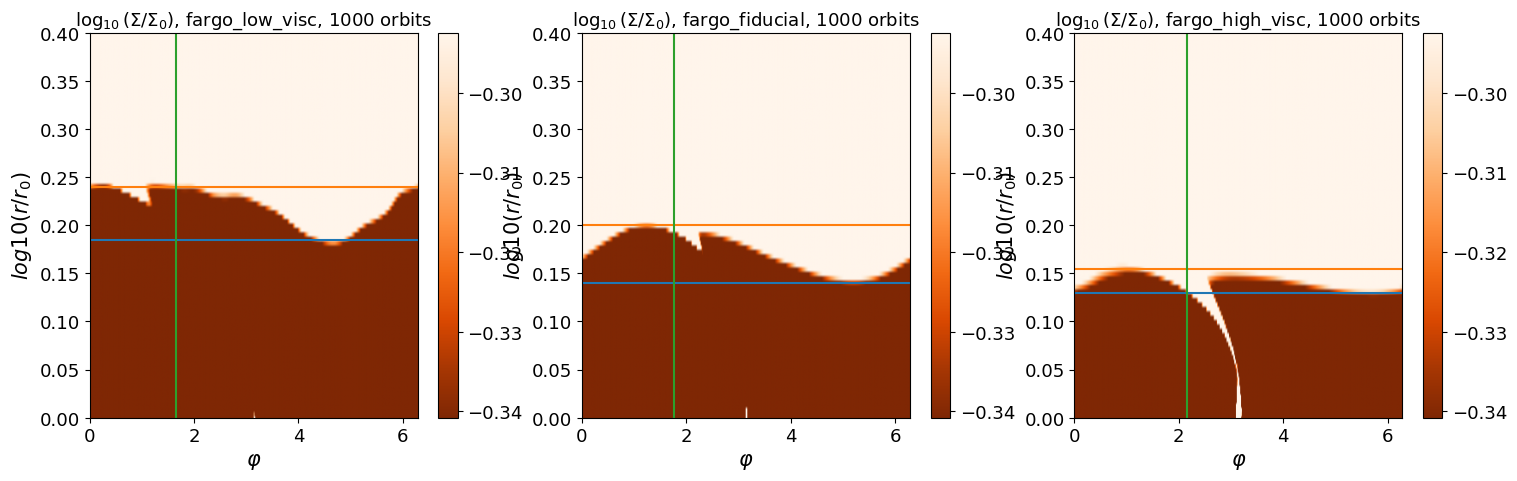

In [40]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_visc=[4,0,3]

r_in_log = [0.185,0.14,0.13]
r_out_log = [0.24,0.20,0.155]
phi_ellipse = [4.8-np.pi,4.9-np.pi,5.3-np.pi]

plt.figure(figsize=(18,5))
frame = 100

for it,i in enumerate(index_for_visc):
    path = paths[i]
    
        
    plt.subplot(1,3,it+1)
    
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (np.log10(0.51),np.log10(0.49)))
    plt.plot([0,np.pi*2],[r_in_log[it],r_in_log[it]])
    plt.plot([0,np.pi*2],[r_out_log[it],r_out_log[it]])
    plt.plot([phi_ellipse[it], phi_ellipse[it]],[-0.5,0.8])
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(0,0.4)
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()


r_in: 1.5135612484362082
r_out: 1.7378008287493754
Eccentricity for fargo_low_visc: 0.06896788945366292


/scratch/3208986/ipykernel_3180633/1669706088.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


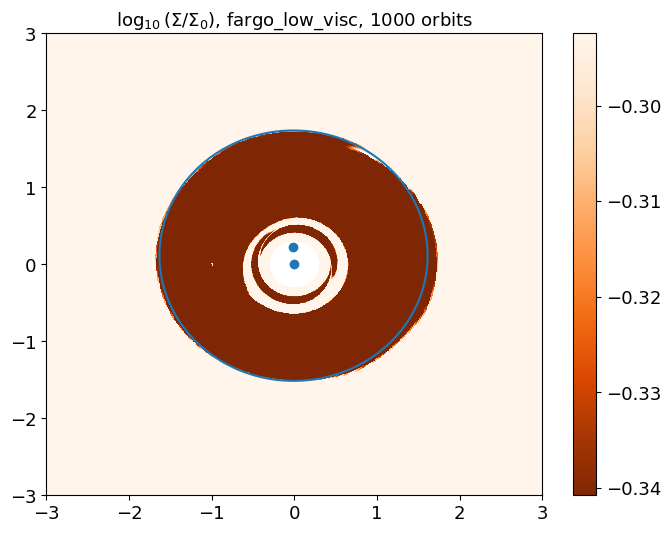

In [41]:
# index_for_mass=[2,0,1]
model_ind = index_for_visc[0]

r_in = np.power(10,0.18)
r_out = np.power(10,0.24)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 4.8- np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

#### I just can't make this look right. That's why I'll give it large uncertainties.

r_in: 1.3489628825916535
r_out: 1.428893958511103
Eccentricity for fargo_high_visc: 0.028774368331997358


/scratch/3208986/ipykernel_3180633/2551373818.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


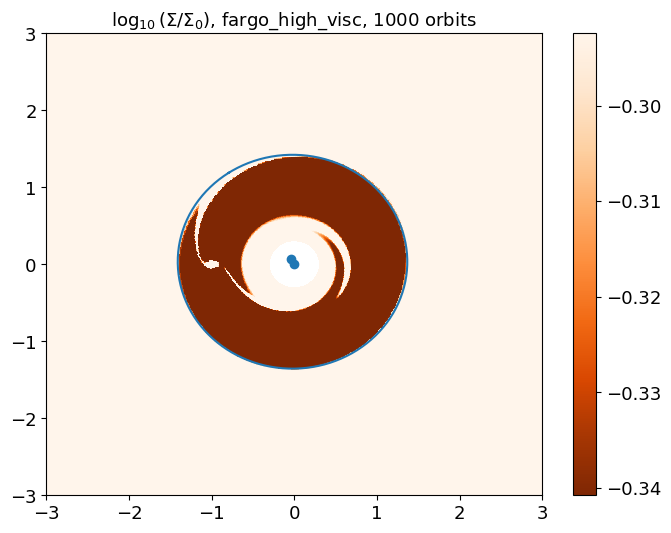

In [42]:
# index_for_mass=[2,0,1]
model_ind = index_for_visc[2]

r_in = np.power(10,0.13)
r_out = np.power(10,0.155)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 5.3- np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

[0.06323659565621458+/-0.016216626840525494
 0.06896788945366301+/-0.008102145062480231
 0.028774368331997358+/-0.008134127319996532]


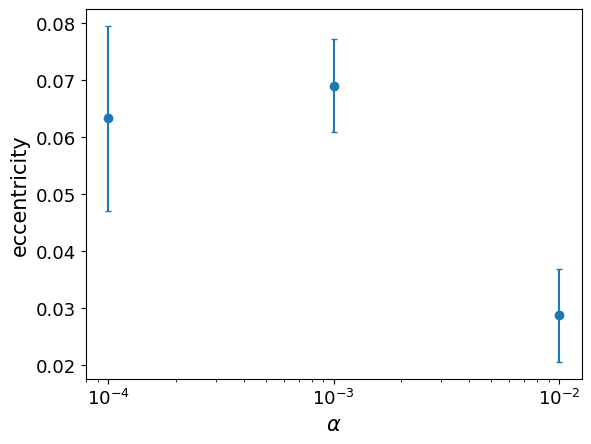

In [43]:

from uncertainties import ufloat
r_in_log = [ufloat(0.185,0.01),ufloat(0.14,0.005),ufloat(0.13,0.005)]
r_out_log = [ufloat(0.24,0.01),ufloat(0.20,0.005),ufloat(0.155,0.005)]



r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
print(ecc)
ecc_values = [ee.nominal_value for ee in ecc]
ecc_errs = [ee.std_dev for ee in ecc]

plt.errorbar([1e-4,1e-3,1e-2],ecc_values, yerr = ecc_errs, fmt="o", capsize=2)
plt.xlabel("$\\alpha$")
plt.ylabel("eccentricity")
plt.xscale("log")

# And again, for different sigma slopes.

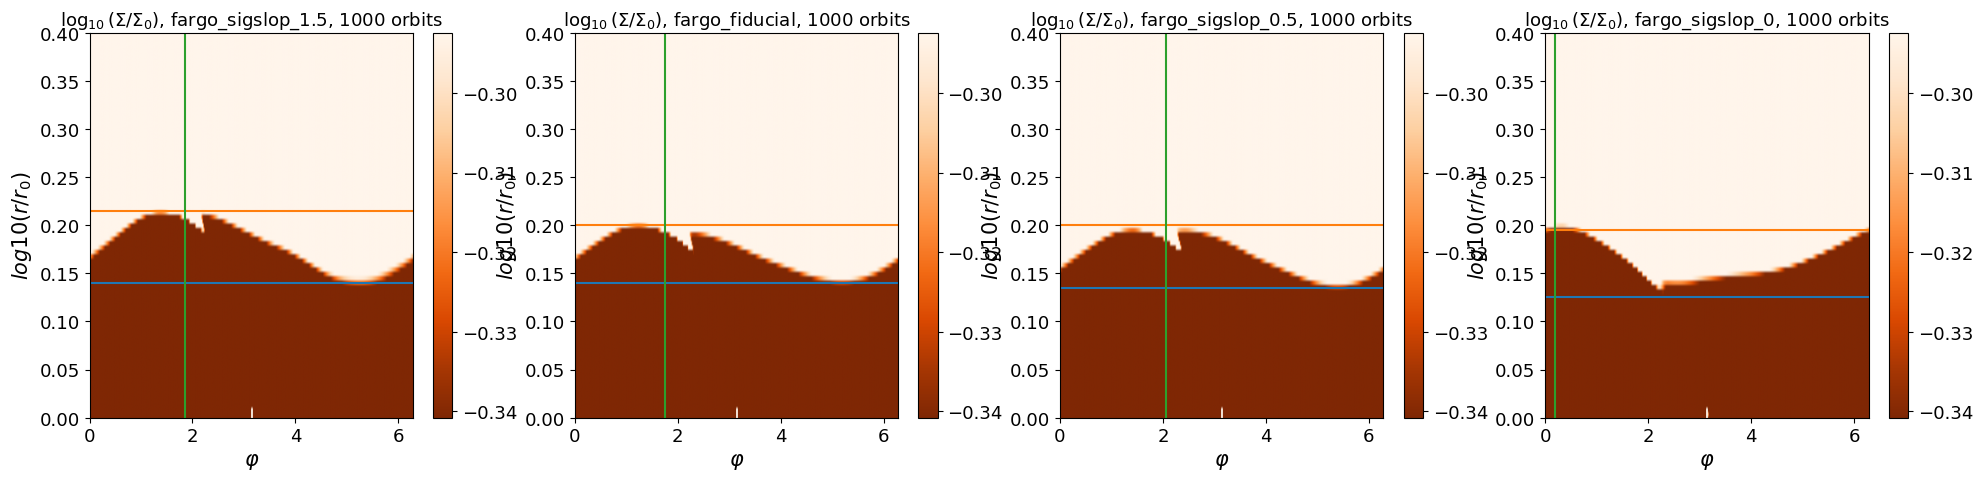

In [44]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_sigslop = [8,0,6,5]

r_in_log = [0.14,0.14,0.135,0.125]
r_out_log = [0.215,0.20,0.20,0.195]
phi_ellipse = [5.0-np.pi,4.9-np.pi,5.2-np.pi,0.2]

plt.figure(figsize=(24,5))
frame = 100

for it,i in enumerate(index_for_sigslop):
    path = paths[i]
    
        
    plt.subplot(1,4,it+1)
    
    plt.imshow(np.log10(rho_cube[i][-1]/rho_cube[i][0]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (np.log10(0.51),np.log10(0.49)))
    plt.plot([0,np.pi*2],[r_in_log[it],r_in_log[it]])
    plt.plot([0,np.pi*2],[r_out_log[it],r_out_log[it]])
    plt.plot([phi_ellipse[it], phi_ellipse[it]],[-0.5,0.8])
    plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylim(0,0.4)
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()


0.14 0.215
r_in: 1.3803842646028848
r_out: 1.6405897731995394
Eccentricity for fargo_sigslop_1.5: 0.08613298404442375


/scratch/3208986/ipykernel_3180633/1228896684.py:27: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


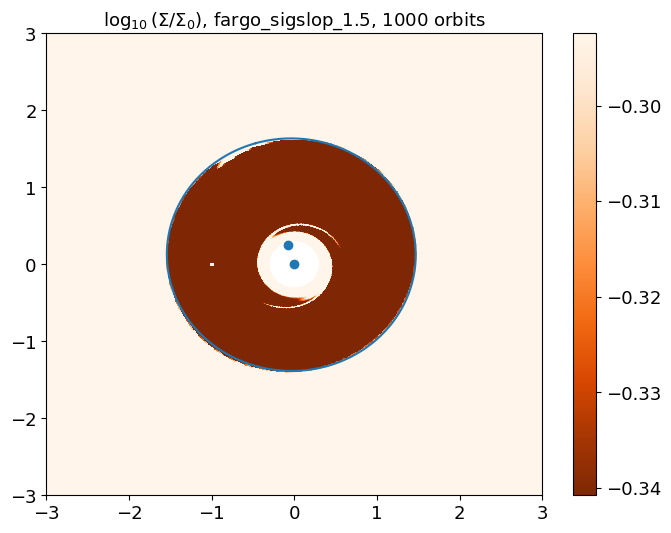

In [45]:
model_ind = index_for_sigslop[0]
print(r_in_log[0],r_out_log[0])
r_in = np.power(10,0.14)
r_out = np.power(10,0.215)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 5.0- np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()



0.135 0.2
r_in: 1.3645831365889245
r_out: 1.5848931924611136
Eccentricity for fargo_sigslop_0.5: 0.07469463433298552


/scratch/3208986/ipykernel_3180633/742589891.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


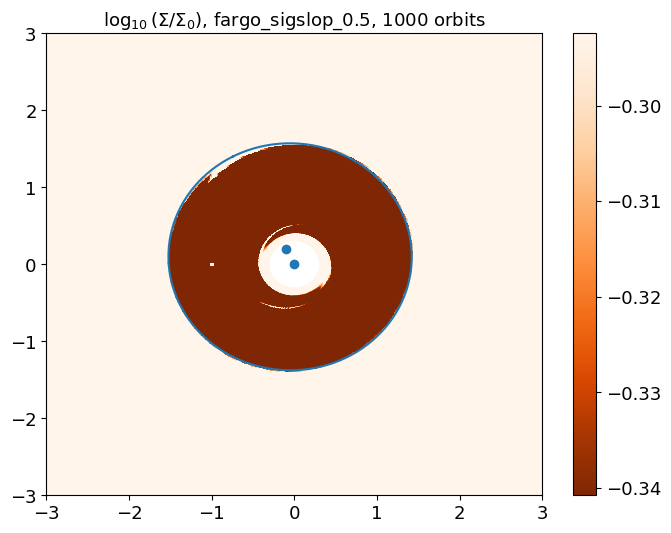

In [46]:
# index_for_mass=[2,0,1]
model_ind = index_for_sigslop[2]
print(r_in_log[2],r_out_log[2])
r_in = np.power(10,0.135)
r_out = np.power(10,0.2)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 5.2- np.pi
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()



0.125 0.195
r_in: 1.333521432163324
r_out: 1.566751070108149
Eccentricity for fargo_sigslop_0: 0.08041645664749132


/scratch/3208986/ipykernel_3180633/3972050390.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))


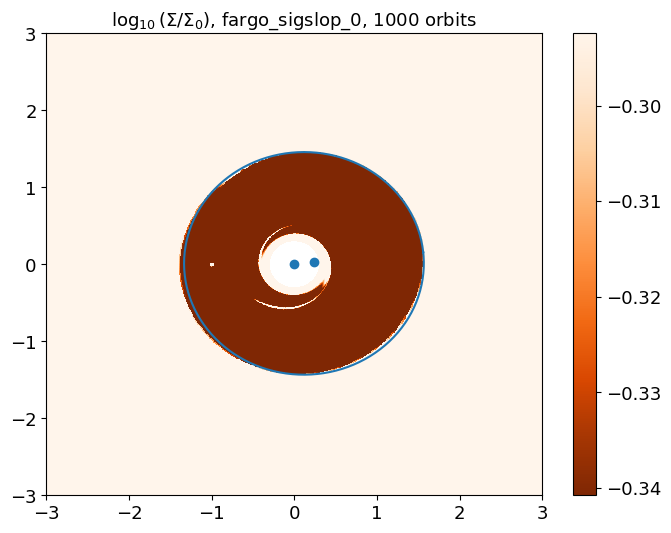

In [47]:
# index_for_mass=[2,0,1]
model_ind = index_for_sigslop[3]
print(r_in_log[3],r_out_log[3])
r_in = np.power(10,0.125)
r_out = np.power(10,0.195)

a = (r_in+r_out)/2
e = (r_out-r_in)/2
b = np.sqrt(a**2-e**2)
print(f"r_in: {r_in}\nr_out: {r_out}")
path = paths[model_ind]
print(f"Eccentricity for {path[43:-5]}: {e/a}")

centerx = e
centery = 0
philist = np.linspace(0,2*np.pi,360)

x_ell_ = centerx + a*np.cos(philist)
y_ell_ = centery + b*np.sin(philist)

phi = 0.1
x_ell = x_ell_*np.cos(phi) - y_ell_*np.sin(phi)
y_ell = +x_ell_*np.sin(phi) + y_ell_*np.cos(phi)

plt.figure(figsize=(8,6))
plt.plot(x_ell,y_ell)
plt.scatter([0,2*e*np.cos(phi)],[0,2*e*np.sin(phi)], zorder=3)
plt.pcolormesh(X, Y,np.log10(rho_cube[model_ind][-1]/rho_cube[model_ind][0]),cmap=cm.Oranges_r,clim = (np.log10(0.51),np.log10(0.49)))

plt.title(f"$\\log_{{10}} \\left(\\Sigma / \\Sigma_0\\right)$, {path[43:-5]}, {(frame)*10} orbits")
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.colorbar()

#### I just can't make this look right. That's why I'll give it large uncertainties.

[0.08613298404442375+/-0.008080471458189787
 0.06896788945366301+/-0.008102145062480231
 0.07469463433298552+/-0.008095447419047249
 0.08041645664749132+/-0.016176444503259103]


Text(0, 0.5, 'eccentricity')

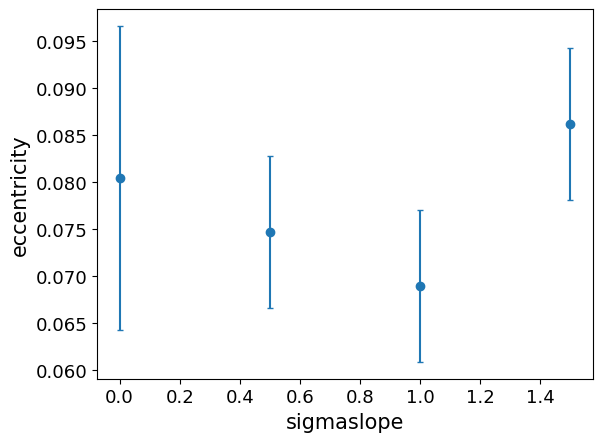

In [48]:
from uncertainties import ufloat


r_in_log = [ufloat(0.14,0.005),ufloat(0.14,0.005),ufloat(0.135,0.005),ufloat(0.125,0.01)]
r_out_log = [ufloat(0.215,0.005),ufloat(0.20,0.005),ufloat(0.20,0.005),ufloat(0.195,0.01)]

r_in = np.power(10,r_in_log)
r_out = np.power(10, r_out_log)

a = (r_in + r_out)/2
e = (r_out-r_in)/2
ecc = e/a
print(ecc)
ecc_values = [ee.nominal_value for ee in ecc]
ecc_errs = [ee.std_dev for ee in ecc]

plt.errorbar([1.5,1.0,0.5,0],ecc_values, yerr = ecc_errs, fmt="o", capsize=2)
plt.xlabel("sigmaslope")
plt.ylabel("eccentricity")
#plt.xscale("log")

# Okay, let's fit everything with sign change.

[ 78 140]
[ 35 153]
[ 29 164]


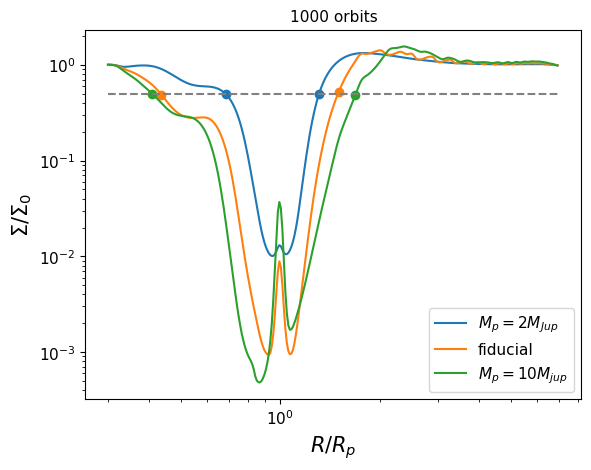

In [58]:
from uncertainties import ufloat

rho_mean = np.mean(rho_cube, axis=3)
index_for_mass=[2,0,1]
gap_width_mass = []
for i in index_for_mass:
    path = paths[i]
    weird = (rho_mean[i][-1]/rho_mean[i][0]-0.5)
    sign_changes = np.where(np.sign(weird[:-1]) != np.sign(weird[1:]))[0]
    r_sign = []
    sig_sign = []
    r_sign_err=[]
    print(sign_changes)
    for s in sign_changes:
        r_sign.append((r_list[s]+r_list[s+1])/2)
        r_sign_err.append((r_list[s+1]-r_list[s]))
        sig_sign.append((rho_mean[i][-1][s]/rho_mean[i][0][s]+rho_mean[i][-1][s+1]/rho_mean[i][0][s+1])/2)
    
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{titles[i]}")
    plt.scatter(r_sign, sig_sign)

    r_left = ufloat(r_sign[0], r_sign_err[0])
    r_right = ufloat(r_sign[1], r_sign_err[1])
    gap_width_mass.append(r_right-r_left)
    
plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()

plt.savefig("img/gap_width_mass.PNG", bbox_inches="tight")

[ 32  52  71 161]
[ 35 153]
[ 72 144]


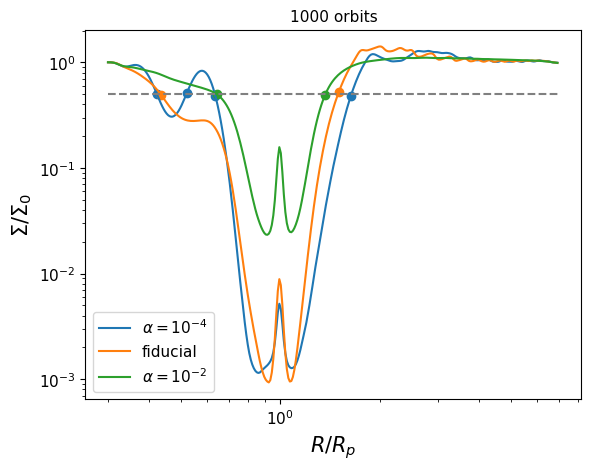

In [59]:
index_for_visc=[4,0,3]
gap_width_visc= []
for i in index_for_visc:
    path = paths[i]
    weird = (rho_mean[i][-1]/rho_mean[i][0]-0.5)
    sign_changes = np.where(np.sign(weird[:-1]) != np.sign(weird[1:]))[0]
    r_sign = []
    sig_sign = []
    r_sign_err=[]
    print(sign_changes)
    for s in sign_changes:
        r_sign.append((r_list[s]+r_list[s+1])/2)
        r_sign_err.append((r_list[s+1]-r_list[s]))
        sig_sign.append((rho_mean[i][-1][s]/rho_mean[i][0][s]+rho_mean[i][-1][s+1]/rho_mean[i][0][s+1])/2)
    
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{titles[i]}")
    plt.scatter(r_sign, sig_sign)

    r_left = ufloat(r_sign[0], r_sign_err[0])
    r_right = ufloat(r_sign[-1], r_sign_err[-1])
    gap_width_visc.append(r_right-r_left)
    
plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()
plt.savefig("img/gap_width_visc.PNG",bbox_inches="tight")

[ 38 155]
[ 35 153]
[ 32 152]
[ 31 150]


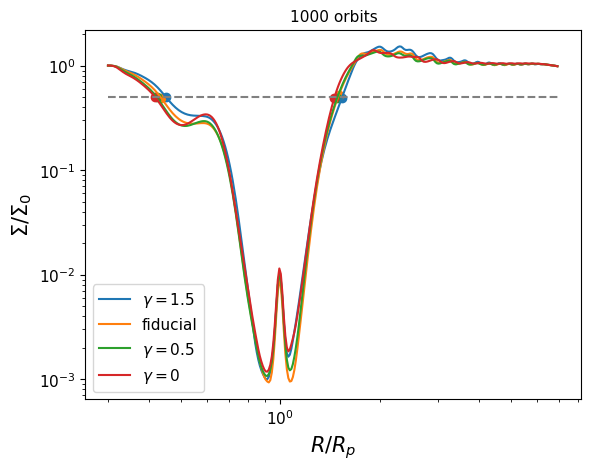

In [60]:
index_for_sigslop = [8,0,6,5]
gap_width_sigslop= []
for i in index_for_sigslop:
    path = paths[i]
    weird = (rho_mean[i][-1]/rho_mean[i][0]-0.5)
    sign_changes = np.where(np.sign(weird[:-1]) != np.sign(weird[1:]))[0]
    r_sign = []
    sig_sign = []
    r_sign_err=[]
    print(sign_changes)
    for s in sign_changes:
        r_sign.append((r_list[s]+r_list[s+1])/2)
        r_sign_err.append((r_list[s+1]-r_list[s]))
        sig_sign.append((rho_mean[i][-1][s]/rho_mean[i][0][s]+rho_mean[i][-1][s+1]/rho_mean[i][0][s+1])/2)
    
    plt.plot(r_list,rho_mean[i][-1]/rho_mean[i][0], label=f"{titles[i]}")
    plt.scatter(r_sign, sig_sign)

    r_left = ufloat(r_sign[-2], r_sign_err[-2])
    r_right = ufloat(r_sign[-1], r_sign_err[-1])
    gap_width_sigslop.append(r_right-r_left)
    
plt.plot([0.3,7],[0.5,0.5], color="grey", linestyle="--")

        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()
plt.savefig("img/gap_width_sigslop.PNG",bbox_inches="tight")

# Summary

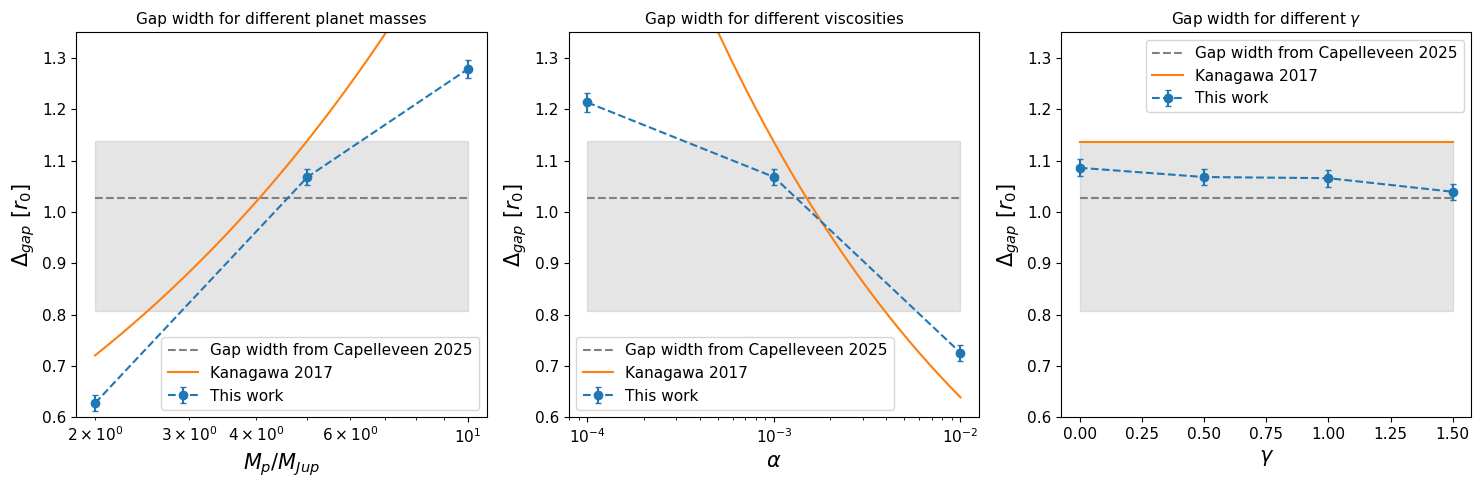

In [61]:
from uncertainties import ufloat

ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
mjup = mstar*0.00177/2


def ufloat_arr(arr):
    values= [ee.nominal_value for ee in arr]
    errs = [ee.std_dev for ee in arr]
    return values, errs

r0 = 57
gap_obs_lower = 46.03/r0
gap_obs = 58.5/r0
gap_obs_upper = 64.86/r0

plt.figure(figsize=(18,5))
plt.subplot(1,3,1)

gap_mass_values , gap_mass_errs = ufloat_arr(gap_width_mass)
plt.errorbar([2,5,10],gap_mass_values, yerr = gap_mass_errs, fmt="o--", capsize=2, label="This work")



plt.xlabel("$M_p/M_{Jup}$")
plt.ylabel("$\\Delta_{gap}$ [$r_0$]")
plt.xscale("log")

plt.plot([2,10,],[gap_obs,gap_obs], color="gray", linestyle="dashed", label="Gap width from Capelleveen 2025")
plt.fill_between([2,10], gap_obs_lower,gap_obs_upper, alpha=0.2, color="gray")

plt.ylim(0.6,1.35)
masses = np.linspace(2,10,100)
gap_mass_pred = 0.41*np.sqrt(masses*mjup/mstar)*0.069**(-3/4)*(1e-3)**(-1/4)
plt.plot(masses, gap_mass_pred, label="Kanagawa 2017")
plt.title("Gap width for different planet masses")
plt.legend()


plt.subplot(1,3,2)
gap_visc_values , gap_visc_errs = ufloat_arr(gap_width_visc)
plt.errorbar([1e-4,1e-3,1e-2],gap_visc_values, yerr = gap_visc_errs, fmt="o--", capsize=2, label="This work")
plt.xlabel("$\\alpha$")
plt.ylabel("$\\Delta_{gap}$ [$r_0$]")
plt.xscale("log")
plt.ylim(0.6,1.35)

plt.title("Gap width for different viscosities")
plt.plot([1e-4,1e-2,],[gap_obs,gap_obs], color="gray", linestyle="dashed", label="Gap width from Capelleveen 2025")
plt.fill_between([1e-4,1e-2], gap_obs_lower,gap_obs_upper, alpha=0.2, color="gray")

viscs = np.linspace(1e-4,1e-2,100)
gap_visc_pred = 0.41*np.sqrt(0.0044)*0.069**(-3/4)*(viscs)**(-1/4)
plt.plot(viscs, gap_visc_pred, label="Kanagawa 2017")


plt.legend()

plt.subplot(1,3,3)
gap_sigslop_values , gap_sigslop_errs = ufloat_arr(gap_width_sigslop)
plt.errorbar([0,0.5,1.0,1.5],gap_sigslop_values, yerr = gap_sigslop_errs, fmt="o--", capsize=2, label="This work")
plt.xlabel("$\\gamma$")
plt.ylabel("$\\Delta_{gap}$ [$r_0$]")
plt.ylim(0.6,1.35)
plt.title("Gap width for different $\\gamma$")
plt.plot([0,1.5,],[gap_obs,gap_obs], color="gray", linestyle="dashed", label="Gap width from Capelleveen 2025")
plt.fill_between([0,1.5], gap_obs_lower,gap_obs_upper, alpha=0.2, color="gray")

gap_sigslop_pred = 0.41*np.sqrt(0.0044)*0.069**(-3/4)*(1e-3)**(-1/4)
plt.plot([0,1.5], gap_sigslop_pred*np.ones(2), label="Kanagawa 2017")

plt.legend()

plt.savefig("img/Gap_widths.PNG",bbox_inches="tight")

#print(gap_width_mass[1])

I used webplot digiztizer on this figure:

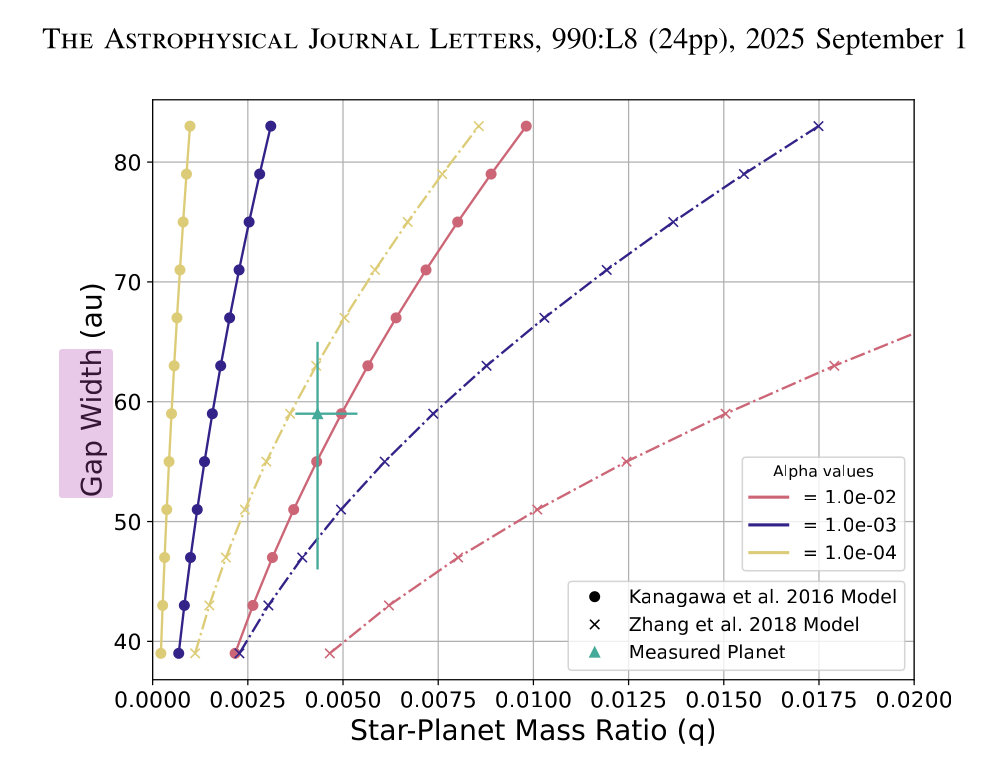

from the Capelleveen paper.
Points obtained:

| x | y |
| -------- | ------- |
|0.004321631878557874,| 58.88792533507346|
|0.004321631878557874, |46.03724660204178|
|0.004321631878557874, |64.86077601380649|
|0.0037523719165085383, |58.89135978431659|
|0.005346299810246679, |58.97224106399238|


This means the gap is at $58.8_{- 12.9}^{+6.0}$ au

Kanagawa 2017:

$\Delta_{gap} = R_p \cdot 0.41 \cdot \left(\frac{M_p}{M_*}\right)^{1/2} \left(\frac{H_p}{R_p}\right)^{-3/4} \alpha^{-1/4} $

In [65]:
rin = 39.5
rout= 98.5
print((rout-rin)/(rout+rin))

0.427536231884058


# 

In [90]:
64.86 - 58.88

5.979999999999997